# WGTDA: Biomarker Discovery Tutorial

This tutorial demonstrates the **WGTDA biomarker discovery framework** for identifying topologically significant gene interactions from a population cohort using a ** gene expression dataset.

A gene co-expression matrix is constructed from expression data and used to build a **Rips simplicial complex**. **Persistent homology** is then computed, and birth–death intervals are extracted to identify **gene interaction cycles** — groups of genes forming connected components, loops, or voids in the co-expression space.

These interactions are candidate **biomarkers** reflecting coordinated gene activity patterns between patient groups.

![Biomarker Discovery Framework](../../docs/imgs/Cohort_framework.png)

## Tutorial Steps
1. Import required modules.
2. Load gene expression data and explore dataset dimensions.
3. Select genes of interest (with optional DEG filtering).
4. Choose and compute a co-expression matrix.
5. Build the Rips complex and run biomarker discovery.
6. Explore the interactions DataFrame.
7. Visualise the persistence diagram and lifespan distribution.


## Step 1: Import Modules

Import the required libraries:
- **`src.tda.pipeline_biomarker`** — builds the Rips complex, computes persistent homology, extracts gene interaction cycles.
- **`src.correlation.*`** — co-expression methods: DTEM, wTO, Pearson, distance correlation.
- **`pandas` / `numpy`** — data loading and manipulation.
- **`matplotlib`** — visualisation.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import src.tda.pipeline_biomarker as wgtda_bio
import src.correlation.dtem as dtem
import src.correlation.wto as wto
import src.correlation.pearson as pearson
import src.correlation.distance_corr as dc


## Step 2: Load Gene Expression Data

Load the gene expression dataset. This tutorial uses the **CPTAC Radiotherapy Response** dataset, where each row is a patient sample and columns are gene FPKM values, with a `phenotype` column indicating treatment response (**Resistant** or **Sensitive**).


In [2]:
import numpy as np

project_root = os.path.abspath('../..')
cisplatin_complete_progression_path = os.path.join(project_root, 'data/paper/biomarker_discovery/Cisplatin_TCGA/Cisplatin_Complete_Progressive.csv')
cisplatin_complete_response_path = os.path.join(project_root, 'data/paper/biomarker_discovery/Cisplatin_TCGA/Cisplatin_Complete_Response.csv')

cisplatin_complete_progression_df = pd.read_csv(cisplatin_complete_progression_path)
cisplatin_complete_response_df = pd.read_csv(cisplatin_complete_response_path)

print(f'Progression samples : {cisplatin_complete_progression_df.shape[0]}')
print(f'Response samples    : {cisplatin_complete_response_df.shape[0]}')
cisplatin_complete_response_df.head(2)
cisplatin_complete_progression_df.head(2)

Progression samples : 103
Response samples    : 322


,AKT3,CDK2,CDK4,CDK6,CDKN1A,CDKN1B,CDKN2A,APC2,CDKN2B,LAMC3,...,WNT3A,CCNE1,PIAS2,CCNE2,TRAF4,ARNT2,FGF19,RBX1,CDC42,CDH1
0,4.7333,38.4963,33.9502,55.1793,4.4653,51.3831,26.7189,2.5196,16.7225,0.1524,...,0.0000,15.5026,27.8752,17.4663,31.9630,0.3842,0.0,49.6361,53.7622,0.2436
1,11.5432,45.7660,66.8953,12.7528,107.4459,157.6743,59.2676,0.3244,25.8717,23.0589,...,4.5178,28.1910,6.5501,9.0766,39.1543,28.8105,0.0,75.6435,57.0272,145.2728


In [3]:

gene_list = cisplatin_complete_progression_df.columns[1:]
gene_dict = {i: gene_list[i] for i in range(len(gene_list))}
X_progression = cisplatin_complete_progression_df.iloc[:, 1:].values
X_response = cisplatin_complete_response_df.iloc[:, 1:].values


## Step 4: Compute the Co-expression Matrix

WGTDA supports five co-expression methods to construct the gene × gene distance matrix used to weight the Rips complex:

| Method | Description |
|---|---|
| `dtem` | Distance to Empirical Measure — robust, outlier-resistant (recommended default) |
| `pearson` | Pearson correlation coefficient |
| `dc` | Distance correlation — captures non-linear dependencies |
| `wto_pearson` | Weighted Topological Overlap using Pearson adjacency |
| `wto_dc` | Weighted Topological Overlap using distance correlation adjacency |

Set `coexpression_method` to one of the strings above.


In [4]:
coexpression_method = 'pearson'  # Options: dtem, pearson, dc, wto_pearson, wto_dc

print(f'Computing co-expression matrix using: {coexpression_method}...')

if coexpression_method == 'dtem':
    coexpression_matrix_progression = dtem.compute_dtem_matrix(X_progression)
    coexpression_matrix_response = dtem.compute_dtem_matrix(X_response)

elif coexpression_method == 'wto_dc':
    coexpression_matrix_progression = wto.compute_wto_matrix(X_progression, adj_matrix='dc')
    coexpression_matrix_response = wto.compute_wto_matrix(X_response, adj_matrix='dc')
elif coexpression_method == 'wto_pearson':
    coexpression_matrix_progression = wto.compute_wto_matrix(X_progression, adj_matrix='pearson')
    coexpression_matrix_response = wto.compute_wto_matrix(X_response, adj_matrix='pearson')
elif coexpression_method == 'dc':
    coexpression_matrix_progression = dc.compute_distance_correlation_matrix(X_progression)
    coexpression_matrix_response = dc.compute_distance_correlation_matrix(X_response)
elif coexpression_method == 'pearson':
    coexpression_matrix_progression = pearson.compute_pearson_correlation_matrix(X_progression)
    coexpression_matrix_response = pearson.compute_pearson_correlation_matrix(X_response)
else:
    raise ValueError(f'Unsupported coexpression_method: {coexpression_method}')

print(f'Co-expression matrix shape (progression): {coexpression_matrix_progression.shape}')
print(f'Co-expression matrix shape (response): {coexpression_matrix_response.shape}')


Computing co-expression matrix using: pearson...


/Users/ndivhuwonyase/Desktop/Github/WGTDA/src/correlation/pearson.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(df[:, i], df[:, j])


Co-expression matrix shape (progression): (325, 325)
Co-expression matrix shape (response): (325, 325)


In [ ]:
print(f'Progression data: {X_progression}')

Progression data: [[3.849630e+01 3.395020e+01 5.517930e+01 ... 4.963610e+01 5.376220e+01
  2.436000e-01]
 [4.576600e+01 6.689530e+01 1.275280e+01 ... 7.564350e+01 5.702720e+01
  1.452728e+02]
 [3.638710e+01 1.695422e+02 1.107050e+01 ... 1.128449e+02 8.511190e+01
  2.102037e+02]
 ...
 [8.041800e+00 4.236650e+01 4.707240e+01 ... 3.535840e+01 2.688080e+01
  1.699106e+02]
 [4.206050e+01 7.572800e+01 4.163920e+01 ... 7.577700e+01 4.362120e+01
  2.119292e+02]
 [1.297441e+02 6.296480e+01 6.982200e+00 ... 8.326220e+01 6.519150e+01
  4.559679e+02]]


: 

## Step 5: Run Biomarker Discovery

`run_biomarker_discovery` performs the following steps:
1. Builds a **Rips complex** from the co-expression matrix using GUDHI.
2. Computes **persistent homology** up to `max_dim` dimensions:
   - Dimension 0 — connected components (co-expressed gene clusters)
   - Dimension 1 — loops (cyclic gene interaction patterns)
   - Dimension 2 — voids (higher-order co-expression structure)
3. Saves a **persistence diagram** to disk.
4. Extracts birth–death simplex pairs and maps them back to **gene names**, returning an interactions DataFrame.

| Parameter | Value | Description |
|---|---|---|
| `max_dim` | 2 | Maximum homological dimension. Higher = more topological detail but slower. |


In [ ]:
max_dim = 2
output_dir = os.path.join(project_root, 'output')
os.makedirs(output_dir, exist_ok=True)
diagram_path = os.path.join(output_dir, 'persistence_diagram_biomarker.png')

print(f'Running WGTDA biomarker discovery for Cisplatin Complete Progression...')
results_progression = wgtda_bio.run_biomarker_discovery(
    matrix=coexpression_matrix_progression,
    gene_dict=gene_dict,
    max_dim=max_dim,
    save_plot=True,
    filename=diagram_path,
    title=f'WG-TDA Biomarker Discovery ({coexpression_method.upper()})',
)

print(f'Running WGTDA biomarker discovery for Cisplatin Complete Response...')
results_response = wgtda_bio.run_biomarker_discovery(
    matrix=coexpression_matrix_response,
    gene_dict=gene_dict,
    max_dim=max_dim,
    save_plot=True,
    filename=diagram_path,
    title=f'WG-TDA Biomarker Discovery ({coexpression_method.upper()})',)
print(f'Done. Persistence diagram saved to: {diagram_path}')


Running WGTDA biomarker discovery for Cisplatin Complete Progression...


## Step 6: Explore the Interactions DataFrame

The `interactions` DataFrame contains one row per topological feature (birth–death pair). Each row identifies the genes involved and the homological dimension:

| Column | Description |
|---|---|
| `interaction_id` | Unique index for the interaction |
| `betti_number` | Homological dimension (0 = components, 1 = loops, 2 = voids) |
| `birth` | Filtration value at which the feature appears |
| `death` | Filtration value at which the feature disappears |
| `lifespan` | Persistence = death − birth (longer → more significant) |
| `birth_geneset` | Genes forming the birth simplex |
| `death_geneset` | Genes forming the death simplex |
| `geneset` | Combined gene set for the interaction |

Features with high lifespan are the most topologically stable and strongest biomarker candidates.


In [ ]:
interactions_response  = results_response['interactions']

print(f'Total interactions found: {len(interactions_response)}')
print(f'\nBreakdown by Betti number:\n{interactions_response["betti_number"].value_counts().sort_index()}')
interactions_response.head(10)


Total interactions found: 0

Breakdown by Betti number:
Series([], Name: count, dtype: int64)


,interaction_id,betti_number,birth,death,lifespan,birth_nodes,death_nodes,birth_geneset,death_geneset,geneset


In [ ]:
# Top 10 most persistent interactions (strongest biomarker candidates)
top_interactions = interactions_df.sort_values('lifespan', ascending=False).head(10)
top_interactions[['interaction_id', 'betti_number', 'birth', 'death', 'lifespan', 'geneset']]


,interaction_id,betti_number,birth,death,lifespan,geneset
0,0,0,0.0,inf,inf,[CSF2RA]


In [ ]:
# Save full interactions table
interactions_output = os.path.join(output_dir, 'interactions.csv')
interactions_df.to_csv(interactions_output, index=False)
print(f'Saved interactions to {interactions_output}')


Saved interactions to /Users/ndivhuwonyase/Desktop/Github/WGTDA/output/interactions.csv


## Step 7: Visualise the Persistence Diagram

The **persistence diagram** plots each topological feature at coordinates $(birth, death)$.
Points far from the diagonal have high $lifespan = death - birth$ and represent stable, biologically meaningful features.
Points near the diagonal are likely topological noise.

Colours represent homological dimensions:
- **Dim 0** — connected components
- **Dim 1** — loops
- **Dim 2** — voids


<Figure size 700x600 with 0 Axes>

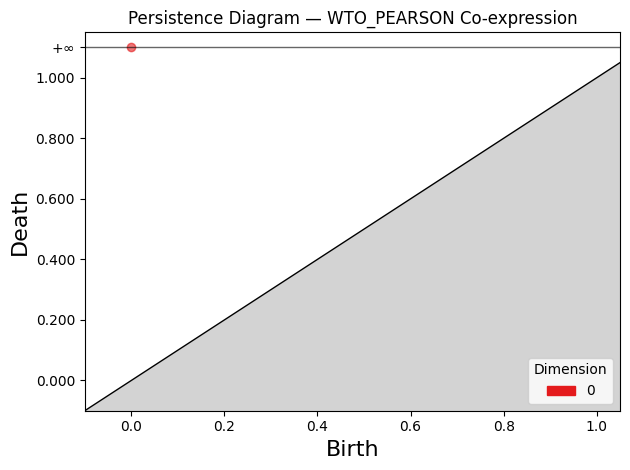

In [ ]:
import gudhi as gd

diagrams = results['diagrams']

plt.figure(figsize=(7, 6))
gd.plot_persistence_diagram(diagrams)
plt.title(f'Persistence Diagram — {coexpression_method.upper()} Co-expression')
plt.tight_layout()
plt.show()


/var/folders/vw/pw_738611cg5z6sj7sj8vd_r0000gn/T/ipykernel_33373/1353482319.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


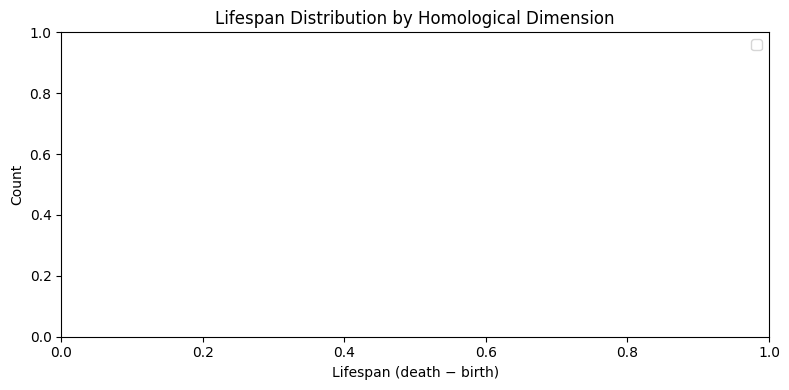

In [ ]:
# Lifespan distribution by homological dimension
finite_df = interactions_df[interactions_df['lifespan'] < float('inf')]

fig, ax = plt.subplots(figsize=(8, 4))
for dim, group in finite_df.groupby('betti_number'):
    ax.hist(group['lifespan'], bins=20, alpha=0.6, label=f'Dim {int(dim)}')

ax.set_xlabel('Lifespan (death − birth)')
ax.set_ylabel('Count')
ax.set_title('Lifespan Distribution by Homological Dimension')
ax.legend()
plt.tight_layout()
plt.show()


## Conclusion

This tutorial demonstrated the **WGTDA biomarker discovery framework** for extracting topologically significant gene interactions from gene expression data.

**Key takeaways:**
- The co-expression matrix (DTEM, Pearson, distance correlation, or wTO) encodes gene-level similarity for the Rips complex.
- Persistent homology in dimensions 0, 1, and 2 captures connected, cyclic, and higher-order co-expression patterns.
- Long-lived topological features (high lifespan) are the most statistically robust biomarker candidates.

**Next steps:**
- Try different co-expression methods (`pearson`, `wto_dc`, etc.) and compare the resulting interaction sets.
- Apply DEG filtering (`padj_threshold`, `log2fc_threshold`) to focus on statistically significant genes.
- Use the saved `interactions.csv` for downstream enrichment analysis or network visualisation.
- See `tutorial_prediction.ipynb` to use WGTDA persistence landscapes for patient phenotype classification.
